In this showcase I will show how all the **functions work and what their output looks like**. Lets start from ```visualize_triangulation_2D```

In [1]:
import networkx
import matplotlib.pyplot as plt

def visualize_triangulation_2D(figure): # 2D visualization
    if len(figure[0]) == 3:
        G = networkx.Graph() # create empty graph
        for a,b,c in figure: # add edges from triangle
            G.add_edge(a,b)
            G.add_edge(b,c)
            G.add_edge(c,a)
        pos = networkx.spring_layout(G, seed=1) # define vertices position
        plt.figure(figsize=(5,5))
        networkx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=500, font_size=10)
        plt.axis("off")
        plt.show()
    elif len(figure[0]) == 4:
        G = networkx.Graph() # create empty graph
        for a,b,c,d in figure: # add edges from triangle
            G.add_edge(a,b)
            G.add_edge(a,c)
            G.add_edge(a,d)
            G.add_edge(b,c)
            G.add_edge(b,d)
            G.add_edge(c,d)
        pos = networkx.spring_layout(G, seed=1) # define vertices position
        plt.figure(figsize=(5,5))
        networkx.draw(G, pos, with_labels=True, node_color="lightblue", node_size=500, font_size=10)
        plt.axis("off")
        plt.show()



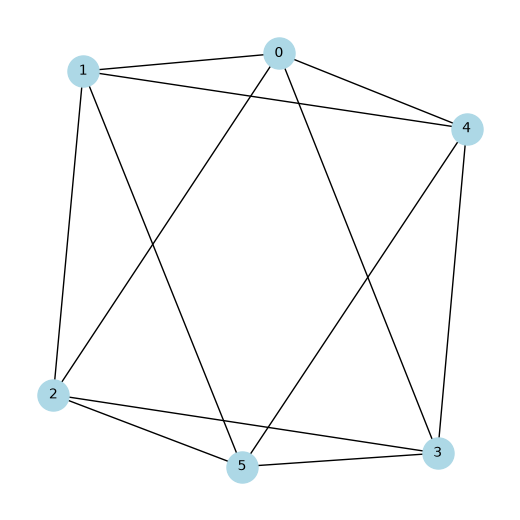

In [2]:
import PySimplicial.utils

octahedron = [(0,1,2), (0,2,3), (0,3,4), (0,4,1),(5,2,1), (5,3,2), (5,4,3), (5,1,4)] #8 triangles list
PySimplicial.utils.visualize_triangulation_2D(octahedron)

Its *basic 2D spring_layout based function* (spring_layout have some **restrictions**, like, **we cant visualize torus correctly**, but with figures without holes it works correct). Next is the same function but work with **tetrahedrons**

In [3]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def visualize_triangulation_3D(figure, fs1=8, fs2=6, xlim=-1, ylim=-1, zlim = -1, xlimright=1, ylimright=1, zlimright=1, enable_random_face_colors=False, xlab="X axis", ylab="Y axis", zlab="Z axis", facecolor="Purple", edgecolor="White", custom_pos=None, show=True):

    coords = []
    fig = plt.figure(figsize=(fs1, fs2))
    ax = fig.add_subplot(111, projection="3d")
    if custom_pos is not None:
        if not isinstance(custom_pos, dict):
            print("custom pos is not dict")
            return None
    if len(figure[0]) == 3:
        if custom_pos==None:
            G = networkx.Graph() # create empty graph
            for a,b,c in figure: # add edges from triangle
                G.add_edge(a,b)
                G.add_edge(b,c)
                G.add_edge(c,a)
            pos = networkx.spring_layout(G, seed=1, dim=3) # define vertices position
        else:
            pos = custom_pos
            vertices = {v for triangle in figure for v in triangle}
            custom_pos_vertices = set(pos.keys())
            missing = vertices - custom_pos_vertices
            if missing:
                raise ValueError(f"Missing vertices: {missing}")
            for v, coord in pos.items():
                if len(coord) != 3:
                    raise ValueError(f"vertex {v} has {len(coord)} coordinates, expected 3")
        for a,b,c in figure:
            coords.append([pos[a], pos[b], pos[c]])
    elif len(figure[0]) == 4:
        if custom_pos==None:
            G = networkx.Graph() # create empty graph
            for a,b,c,d in figure: # add edges from triangle
                G.add_edge(a,b)
                G.add_edge(a,c)
                G.add_edge(a,d)
                G.add_edge(b,c)
                G.add_edge(b,d)
                G.add_edge(c,d)
            pos = networkx.spring_layout(G, seed=1, dim=3) # define vertices position
        else:
            pos = custom_pos
            vertices = {v for tetrahedron in figure for v in tetrahedron}
            custom_pos_vertices = set(pos.keys())
            missing = vertices - custom_pos_vertices
            if missing:
                raise ValueError(f"Missing vertices: {missing}")
            for v, coord in pos.items():
                if len(coord) != 3:
                    raise ValueError(f"vertex {v} has {len(coord)} coordinates, expected 3")
        for a,b,c,d in figure:
            coords.append([pos[a], pos[b], pos[c]])
            coords.append([pos[a], pos[b], pos[d]])
            coords.append([pos[a], pos[c], pos[d]])
            coords.append([pos[b], pos[c], pos[d]]) 
    else:
        raise ValueError("Unsupported simplex dimension")
    if enable_random_face_colors:
        face_colors = [[random.random() for _ in range(3)] for _ in coords]
        pol = Poly3DCollection(coords, facecolors=face_colors)
    else:
        pol = Poly3DCollection(coords, facecolors=facecolor, edgecolors=edgecolor)
    ax.add_collection3d(pol)
    ax.set_xlim([xlim, xlimright])
    ax.set_ylim([ylim, ylimright])
    ax.set_zlim([zlim, zlimright])
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_zlabel(zlab)
    ax.set_box_aspect([1,1,1])
    if show:
        plt.show()
    return fig, ax
        

Octahedron basic without custom pos


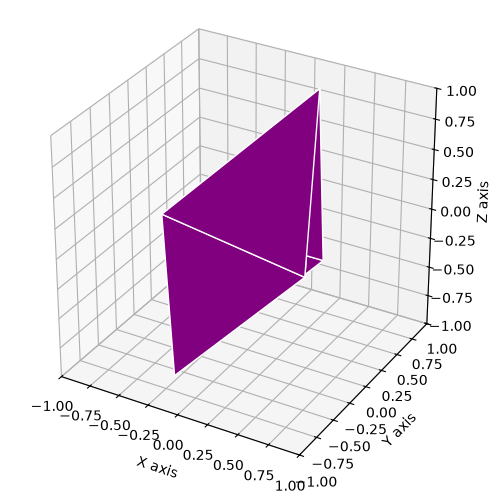

Octahedron with move 1-3


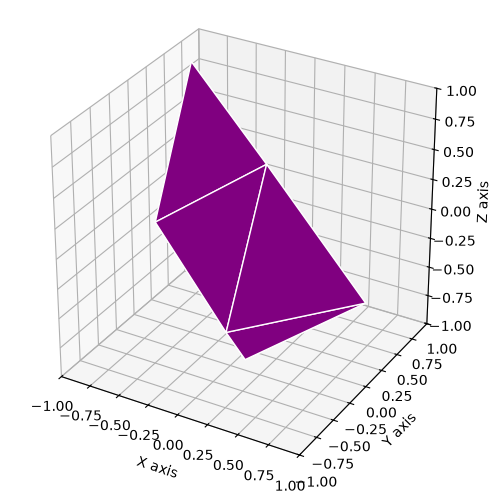

(<Figure size 800x600 with 1 Axes>, <Axes3D: xlabel='X axis', ylabel='Y axis', zlabel='Z axis'>)
Octahedron with custom pos


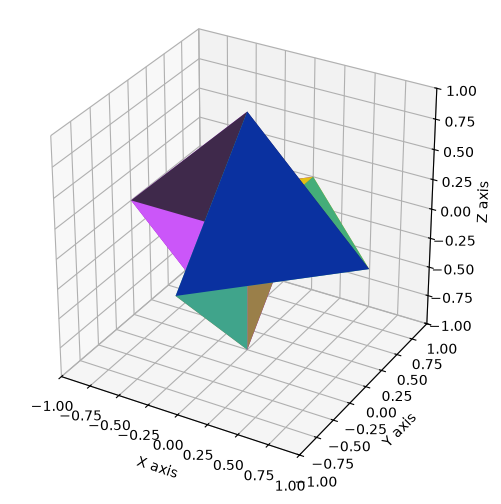

Basic tetrahedron


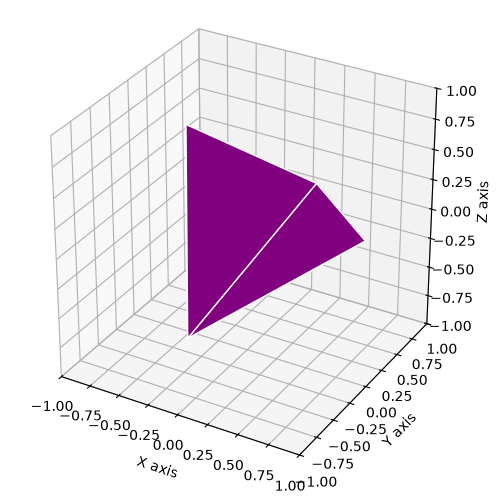

tetrahedron with 1-4 move


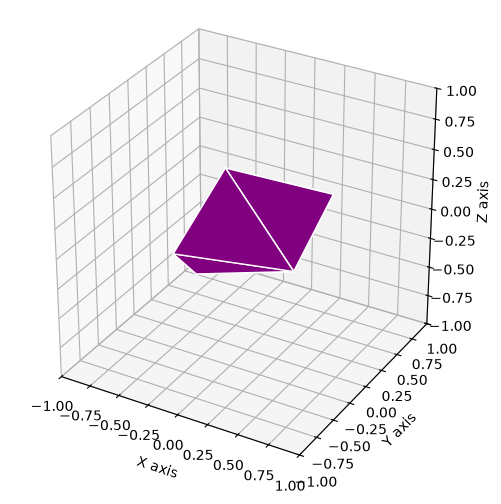

(<Figure size 800x600 with 1 Axes>, <Axes3D: xlabel='X axis', ylabel='Y axis', zlabel='Z axis'>)


In [4]:
octahedron = [(0,1,2), (0,2,3), (0,3,4), (0,4,1),(5,2,1), (5,3,2), (5,4,3), (5,1,4)]
tetrahedron = [(0, 1, 2, 3),(0, 1, 2, 4)]

print("Octahedron basic without custom pos")
PySimplicial.utils.visualize_triangulation_3D(octahedron, enable_random_face_colors=False)


print("Octahedron with move 1-3")
octahedron_with_move_1_3 = PySimplicial.utils.move_1_3(octahedron)
visualize_octahedron_move_1_3 = PySimplicial.utils.visualize_triangulation_3D(octahedron_with_move_1_3, enable_random_face_colors=False)
print(visualize_octahedron_move_1_3)


pos = {0: (1, 0, 0),1: (-1, 0, 0),2: (0, 1, 0),3: (0, -1, 0),4: (0, 0, 1),5: (0, 0, -1)}

print("Octahedron with custom pos")
octahedron = [(0,1,2), (0,2,3), (0,3,4), (0,4,1), (5,2,1), (5,3,2), (5,4,3), (5,1,4)]
PySimplicial.utils.visualize_triangulation_3D(octahedron, custom_pos=pos, enable_random_face_colors=True)

print("Basic tetrahedron")
PySimplicial.utils.visualize_triangulation_3D(tetrahedron, enable_random_face_colors=False)

print("tetrahedron with 1-4 move")
new_tetrahedron_1_4 = PySimplicial.utils.move_1_4(tetrahedron)
visualize_tetrahedron_1_4 = PySimplicial.utils.visualize_triangulation_3D(new_tetrahedron_1_4, enable_random_face_colors=False)
print(visualize_tetrahedron_1_4)

The next feature it is a Pachner Moves, the triangulations of the Piecewise-Linear Manifolds (see more in [OCSSN Mathemathical Introduction](https://github.com/kaifczxc-lab/OCSSN/blob/SiritoriProjects/OCSSN-Maths-Introduction.md)). In pysimplicial we have all 2D & 3D moves

Basic octahedron=[(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
Pachner_move_2_2 Octahedron=[(0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4), (0, 1, 3), (1, 2, 3)]


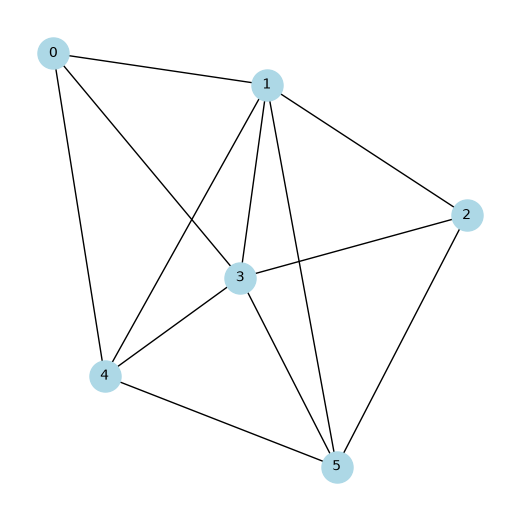

In [5]:
from collections import defaultdict
import random    
from collections import Counter

def move_2_2(tris):
    # we need to construct a mapping : edge -> list of tris containing it
    ett = defaultdict(list) # edge to tris
    for idx, (a,b,c) in enumerate(tris): # first triangle: (0, (0,1,2)) ; second triangle: (1, (0,2,3))
        # for each triangle, we iterate over its three edges for ensure that the edges (a,b) and (b,a) are considered the same
        for edge in [tuple(sorted((a,b))), tuple(sorted((b,c))), tuple(sorted((a,c)))]:
            ett[edge].append(idx) # add the index of the current triangle to the list of triangles that own this edge
    exist=set(ett.keys()) # set of all exist edges ; it is necessary to check whether a new diagonal already exists
    # choose an edge that has exactly two tris
    inter=[e for e, tris in ett.items() if len(tris) == 2] # A move 2/2 can only be done on an edge that is adjacent to exactly two triangles
    random.shuffle(inter)
    #edge=random.choice(inter) # choose random
    for edge in inter:
        t1_idx,t2_idx=ett[edge]
        a,b = edge # a,b = end of this edge
        t1 = tris[t1_idx]
        t2 = tris[t2_idx]
        c = [v for v in t1 if v != a and v != b]
        d = [v for v in t2 if v != a and v != b]
        if not c or not d: # empty check
            continue
        c,d = c[0], d[0]
        new_edge=tuple(sorted((c,d)))
        if c==d or new_edge in exist:
            continue
        new_triangles = [t for i, t in enumerate(tris) if i != t1_idx and i != t2_idx] # all triangles except those with indices 0 and 1 will be empty []
        new_triangles.append((a,c,d))
        new_triangles.append((c,b,d))
        return new_triangles
    return tris

Pachner_move_2_2 = move_2_2(octahedron)
print(f"Basic octahedron={octahedron}")
print(f"Pachner_move_2_2 Octahedron={Pachner_move_2_2}")
visualize_triangulation_2D(Pachner_move_2_2)

Basic octahedron=[(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
Octahedron with move 3-1=[(0, 1, 2), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4), (0, 2, 6), (2, 3, 6), (0, 3, 6)]


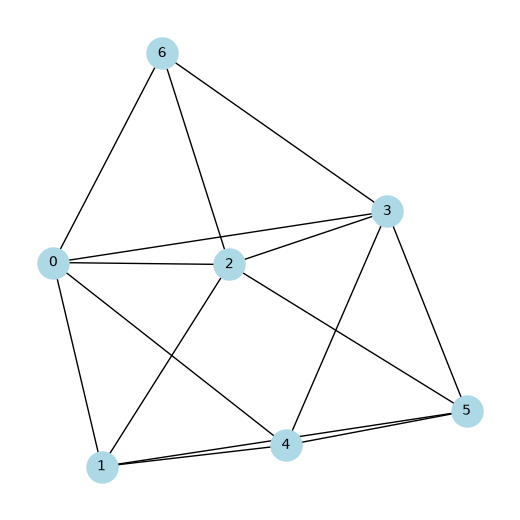

In [6]:

def p_1_3(tris):
    index = random.randrange(len(tris))
    a,b,c = tris[index]
    n_v = max(max(t) for t in tris) + 1 # +1 gives guaranteed unique ID
    n_triangles = [t for i,t in enumerate(tris) if i != index]
    n_triangles += [(a,b,n_v), (b,c,n_v), (a,c,n_v)]
    return n_triangles 

Pachner_move_1_3 = PySimplicial.utils.move_1_3(octahedron)
print(f"Basic octahedron={octahedron}")
print(f"Octahedron with move 3-1={Pachner_move_1_3}")
PySimplicial.utils.visualize_triangulation_2D(Pachner_move_1_3)

Basic octahedron=[(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
Octahedron with move 3-1=[(0, 1, 2), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4), (0, 2, 3)]


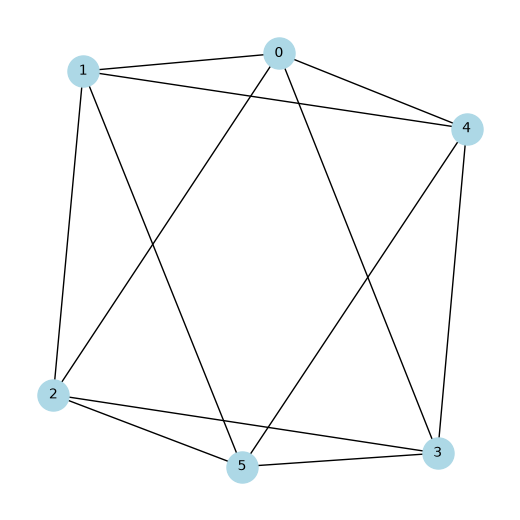

In [7]:
def move_3_1(tris):
    e_count = Counter()
    for (a,b,c) in tris:
        for edge in [tuple(sorted((a,b))), tuple(sorted((b,c))), tuple(sorted((a,c)))]:
            e_count[edge] += 1
    vert_tris = defaultdict(list)
    for i, (a,b,c) in enumerate(tris):
        for v in (a,b,c):
            vert_tris[v].append(i)
    for v, incident in vert_tris.items():
        if len(incident) != 3:
            continue
        others = []
        for i in incident:
            a,b,c = tris[i]
            for u in (a,b,c):
                if u != v and u not in others:
                    others.append(u)
        if len(others) != 3:
            continue
        o1,o2,o3 = others
        new_tri = (o1,o2,o3)
        existing_edges = set(tuple(sorted((a,b))) for a,b,c in tris
                            for a,b in [(a,b), (b,c), (a,c)])
        if tuple(sorted((o1, o2))) in existing_edges and tuple(sorted((o2, o3))) in existing_edges and tuple(sorted((o1, o3))) in existing_edges:
            pass
        new_triangles = [t for i, t in enumerate(tris) if i not in incident]
        new_triangles.append(new_tri)
        return new_triangles
    return None

Pachner_move_3_1 = PySimplicial.utils.move_3_1(Pachner_move_1_3)
print(f"Basic octahedron={octahedron}")
print(f"Octahedron with move 3-1={Pachner_move_3_1}")
PySimplicial.utils.visualize_triangulation_2D(Pachner_move_3_1)


Now from 2D we move to 3D Pachner Moves, there are 4 types: 1-4; 4-1; 2-3; 3-2

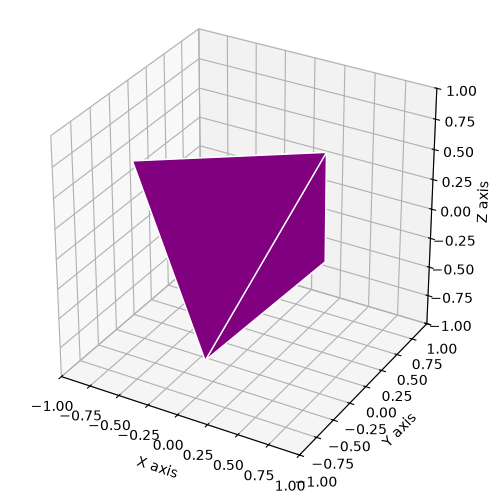

tetrahedron=[(0, 1, 2, 3)]
same tetrahedron but with move 1-4=[(0, 1, 2, 4), (0, 1, 3, 4), (0, 2, 3, 4), (1, 2, 3, 4)]


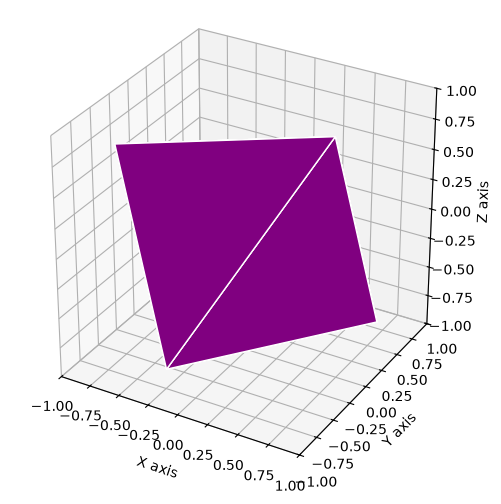

(<Figure size 800x600 with 1 Axes>,
 <Axes3D: xlabel='X axis', ylabel='Y axis', zlabel='Z axis'>)

In [8]:
def move_1_4(tetrahedron):
    index = random.randrange(len(tetrahedron))
    a,b,c,d = tetrahedron[index]
    n_v = max(max(t) for t in tetrahedron) + 1 # +1 gives guaranteed unique ID
    n_triangles = [t for i,t in enumerate(tetrahedron) if i != index]
    n_triangles += [(a, b, c, n_v),(a, b, d, n_v),(a, c, d, n_v),(b, c, d, n_v)]
    return n_triangles 

one_tetrahedron = [(0, 1, 2, 3)]
PySimplicial.utils.visualize_triangulation_3D(one_tetrahedron)

Pachner_move_1_4 = PySimplicial.utils.move_1_4(one_tetrahedron)
print(f"tetrahedron={one_tetrahedron}")
print(f"same tetrahedron but with move 1-4={Pachner_move_1_4}")
PySimplicial.utils.visualize_triangulation_3D(Pachner_move_1_4)

The move 4-1 is the **reverse** of 1-4 (that is, when applied to a figure that was triangulated by the move 1-4, we return to the **original shape**) ; The same situation with 2-3 and 3-2

Pachner_move_1_4=[(0, 1, 2, 4), (0, 1, 3, 4), (0, 2, 3, 4), (1, 2, 3, 4)]
Pachner_move_4_1=[(0, 1, 2, 3)]


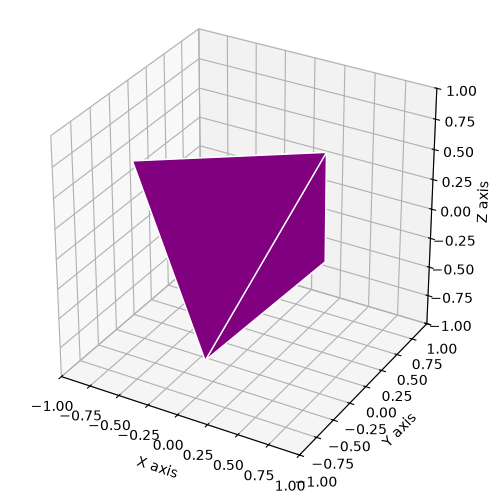

(<Figure size 800x600 with 1 Axes>,
 <Axes3D: xlabel='X axis', ylabel='Y axis', zlabel='Z axis'>)

In [9]:
def move_4_1(tetrahedron):
    vert_tetrahedron = defaultdict(list)
    for i, (a,b,c,d) in enumerate(tetrahedron):
        for v in (a,b,c,d):
            vert_tetrahedron[v].append(i)
    for v, incident in vert_tetrahedron.items():
        if len(incident) != 4:
            continue
        others = []
        for i in incident:
            a,b,c,d = tetrahedron[i]
            for u in (a,b,c,d):
                if u != v and u not in others:
                    others.append(u)
        if len(others) != 4:
            continue
        o1,o2,o3,o4 = others
        new_tetra = (o1,o2,o3,o4)
        new_triangles = [t for i, t in enumerate(tetrahedron) if i not in incident]
        new_triangles.append(new_tetra)
        return new_triangles
    return None

Pachner_move_4_1 = PySimplicial.utils.move_4_1(Pachner_move_1_4)
print(f"Pachner_move_1_4={Pachner_move_1_4}")
print(f"Pachner_move_4_1={Pachner_move_4_1}")
PySimplicial.utils.visualize_triangulation_3D(Pachner_move_4_1)

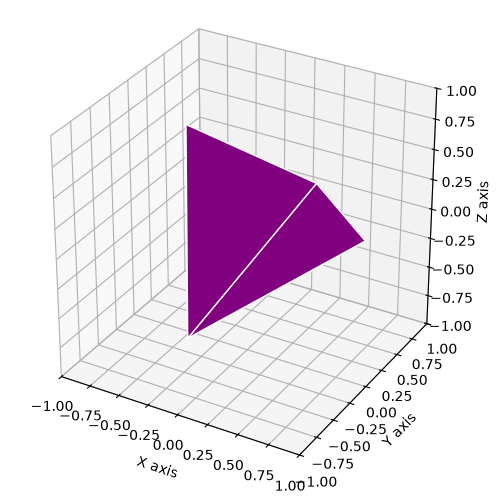

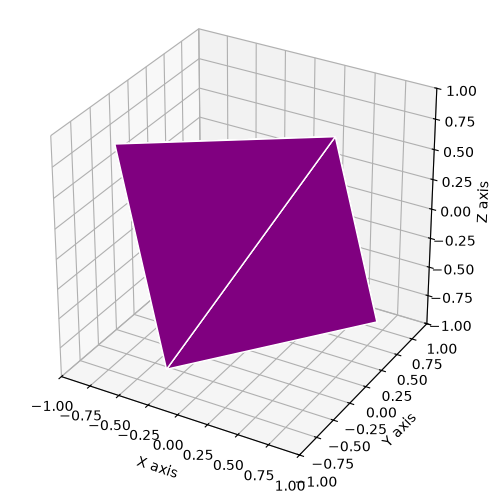

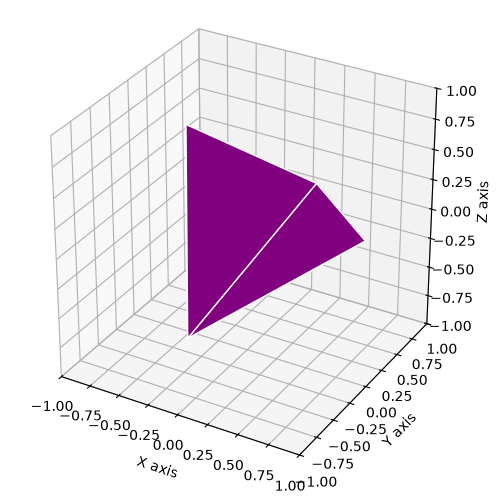

basic tetrahedron=[(0, 1, 2, 3), (0, 1, 2, 4)]
same tetrahedron but with move 2-3=[(0, 1, 3, 4), (1, 2, 3, 4), (0, 2, 3, 4)]
inverse, move 3-2=[(0, 1, 2, 3), (0, 1, 2, 4)]


In [10]:
def move_2_3(tetrahedron):
    # we need to construct a mapping : edge -> list of tris containing it
    ett = defaultdict(list) # edge to tris
    for idx, (a,b,c,d) in enumerate(tetrahedron):
        for edge in [tuple(sorted((a,b,c))), tuple(sorted((a,b,d))), tuple(sorted((a,c,d))), tuple(sorted((b,c,d)))]:
            ett[edge].append(idx) # add the index of the current triangle to the list of triangles that own this edge
    exist=set(ett.keys()) # set of all exist edges ; it is necessary to check whether a new diagonal already exists
    # choose an edge that has exactly two tris
    inter=[e for e, tetrahedron in ett.items() if len(tetrahedron) == 2]
    random.shuffle(inter)
    #edge=random.choice(inter) # choose random
    for edge in inter:
        t1_idx,t2_idx=ett[edge]
        a,b,c = edge # a,b,c = end of this edge
        t1 = tetrahedron[t1_idx]
        t2 = tetrahedron[t2_idx]
        d = [v for v in t1 if v not in edge][0]
        e = [v for v in t2 if v not in edge][0]
        new_tetrahedrons = [t for i, t in enumerate(tetrahedron) if i != t1_idx and i != t2_idx] # all triangles except those with indices 0 and 1 will be empty []
        new_tetrahedrons.append((a, b, d, e))
        new_tetrahedrons.append((b, c, d, e))
        new_tetrahedrons.append((a, c, d, e))
        return new_tetrahedrons
    return tetrahedron

def move_3_2(tetrahedron):
    edge_to_tetrahedrons = defaultdict(list)
    for idx, tetrahedron_ in enumerate(tetrahedron):
        a, b, c, d = tetrahedron_
        for edge in [(a,b), (a,c), (a,d), (b,c), (b,d), (c,d)]:
            edge = tuple(sorted(edge))
            edge_to_tetrahedrons[edge].append(idx)
    for edge, tetrahedron_idx in edge_to_tetrahedrons.items():
        if len(tetrahedron_idx) != 3:
            continue
        i1, i2, i3 = tetrahedron_idx
        t1 = tetrahedron[i1]
        t2 = tetrahedron[i2]
        t3 = tetrahedron[i3]
        u, v = edge
        exts = []
        for t in (t1, t2, t3):
            pair = [x for x in t if x not in (u, v)]
            exts.append(tuple(sorted(pair)))
        all_ext = list({x for pair in exts for x in pair})
        if len(all_ext) != 3:
            continue
        a, b, c = sorted(all_ext)
        new_t1 = tuple(sorted((a, b, c, u)))
        new_t2 = tuple(sorted((a, b, c, v)))
        result = [t for i, t in enumerate(tetrahedron) if i not in tetrahedron_idx]
        result.extend([new_t1, new_t2])
        return result
    return tetrahedron


tetrahedron = [(0, 1, 2, 3),(0, 1, 2, 4)] # Visualize original figure
PySimplicial.utils.visualize_triangulation_3D(tetrahedron)

Pachner_move_2_3 = PySimplicial.utils.move_2_3(tetrahedron) # visualize the same figure but with Pachner Move 2-3 triangulation
PySimplicial.utils.visualize_triangulation_3D(Pachner_move_2_3)

Pachner_move_3_2 = PySimplicial.utils.move_3_2(Pachner_move_2_3) # return this modify to basic form
PySimplicial.utils.visualize_triangulation_3D(Pachner_move_3_2)

print(f"basic tetrahedron={tetrahedron}")
print(f"same tetrahedron but with move 2-3={Pachner_move_2_3}")
print(f"inverse, move 3-2={Pachner_move_3_2}")



This library's code contains more than just triangulation visualizations, and currently only has three torus and bottle of klein generators 

1. A combinatorial torus, which is well suited for calculations (datasets, for example), but is somewhat difficult to visualize

2. A geometric torus, which is difficult to use for calculations, but can be visualized using a custom function (there's no built-in function yet)

3. A combinatorial torus 3D (contains tetrahedrons instead triangles)

4. Geometric 3D bottle of klein (can be visualized by custom function, there's no built-in function yet)

combinatorial torus 2d
[(0, 1, 3), (1, 4, 3), (1, 2, 4), (2, 5, 4), (2, 0, 5), (0, 3, 5), (3, 4, 6), (4, 7, 6), (4, 5, 7), (5, 8, 7), (5, 3, 8), (3, 6, 8), (6, 7, 0), (7, 1, 0), (7, 8, 1), (8, 2, 1), (8, 6, 2), (6, 0, 2)]
geometry torus 3d
{0: (np.float64(3.0), np.float64(0.0), np.float64(0.0)), 1: (np.float64(1.5000000000000002), np.float64(0.0), np.float64(0.8660254037844387)), 2: (np.float64(1.4999999999999996), np.float64(0.0), np.float64(-0.8660254037844385)), 3: (np.float64(-1.4999999999999993), np.float64(2.598076211353316), np.float64(0.0)), 4: (np.float64(-0.7499999999999998), np.float64(1.2990381056766582), np.float64(0.8660254037844387)), 5: (np.float64(-0.7499999999999994), np.float64(1.2990381056766578), np.float64(-0.8660254037844385)), 6: (np.float64(-1.5000000000000013), np.float64(-2.5980762113533156), np.float64(0.0)), 7: (np.float64(-0.7500000000000008), np.float64(-1.299038105676658), np.float64(0.8660254037844387)), 8: (np.float64(-0.7500000000000004), np.float64(-

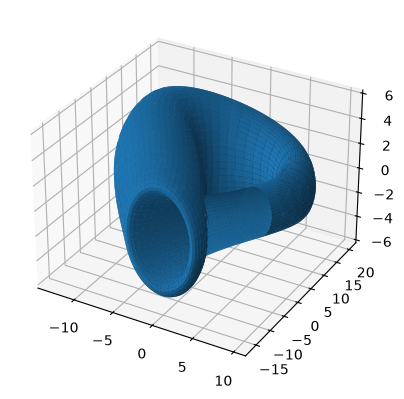

In [11]:
import numpy as np
import matplotlib.pyplot as plt


def combinatorial_torus(m, n):
    def vid(r,c):
        return (r % m) * n + (c % n)
    tris = []
    for r in range(m):
        for c in range(n):
            v00 = vid(r,c)
            v01 = vid(r, c+1)
            v10 = vid(r+1, c)
            v11 = vid(r+1,c+1)
            tris.append((v00, v01, v10))
            tris.append((v01, v11, v10))
    return tris

def geometry_torus(m,n,R,r):
    result = {}
    for id in range(m * n):
        row = id // n
        col = id % n
        u = 2 * np.pi * row / m
        v = 2 * np.pi * col / n
        x = (R + r * np.cos(v)) * np.cos(u)
        y = (R + r * np.cos(v)) * np.sin(u)
        z = r * np.sin(v)
        result[id] = (x,y,z)
    return result

def combinatorial_torus_3D(m, n, p):
    def vid3D(i, j, k):
        return ((i % m) * n + (j % n)) * p + (k % p)
    tets = []
    for i in range(m):
        for j in range(n):
            for k in range(p):
                v000 = vid3D(i, j, k)
                v100 = vid3D(i+1, j, k)
                v010 = vid3D(i, j+1, k)
                v001 = vid3D(i, j, k+1)
                v110 = vid3D(i+1, j+1, k)
                v101 = vid3D(i+1, j, k+1)
                v011 = vid3D(i, j+1, k+1)
                v111 = vid3D(i+1, j+1, k+1)
                tets.extend([(v000, v100, v110, v111),(v000, v100, v101, v111),(v000, v010, v110, v111),(v000, v010, v011, v111),(v000, v001, v101, v111),(v000, v001, v011, v111)])
    return tets


cos = np.cos
sin = np.sin
sqrt = np.sqrt
pi = np.pi


def geometry_bottle_of_klein(u, v):
    """
    returns point cloud / surface
    """
    half = (0 <= u) & (u < pi)
    r = 4*(1 - cos(u)/2)
    x = 6*cos(u)*(1 + sin(u)) + r*cos(v + pi)
    x[half] = ((6*cos(u)*(1 + sin(u)) + r*cos(u)*cos(v))[half])
    y = 16 * sin(u)
    y[half] = (16*sin(u) + r*sin(u)*cos(v))[half]
    z = r * sin(v)
    return x, y, z

combinatorial_torus_2D = PySimplicial.utils.combinatorial_torus(3,3)
print("combinatorial torus 2d")
print(combinatorial_torus_2D)

geometry_torus_3D = PySimplicial.utils.geometry_torus(3,3,2,1)
print("geometry torus 3d")
print(geometry_torus_3D)

combinatorial_torus_3D_ = PySimplicial.utils.combinatorial_torus_3D(3,3,3)
print("combinatorial torus 3d")
print(combinatorial_torus_3D_)

u, v = np.meshgrid(np.linspace(0, 2*np.pi, 3),np.linspace(0, 2*np.pi, 3))
bottle_of_klein = PySimplicial.utils.geometry_bottle_of_klein(u, v)
print("bottle of klein")
print(bottle_of_klein)

print("Bottle of klein visualization")
u, v = np.meshgrid(np.linspace(0, 2*np.pi, 100),np.linspace(0, 2*np.pi, 100))
x, y, z = PySimplicial.utils.geometry_bottle_of_klein(u, v)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z)
plt.show()



The code also has one interesting feature: **converters of information in the form of meshes into data types understandable for popular neural network architectures** (graphs, tensors, vectors)

All of this came from OCSSN, because I needed the data to be understandable by all networks when comparing (in order to attempt to calculate a topological invariant)

In [12]:
# Here we will write functions for converting geometric information (meshes) into input data understandable for popular neural network architectures

import torch
from collections import defaultdict
from collections import Counter
import random
import PySimplicial.utils as ps

class Converters:
    def relabel(self, simplices):
        """
        Renumber vertices of a triangle mesh to consecutive integers starting from 0

        Parameters
        ----------

        figure: list of tuple
            list of tuple with form of (a,b,c) or (a,b,c,d) ; anything else right now unsupported
        
        Returns
        -------

        list of tuple:
            Renumbered triangle mesh list

        Examples
        --------

        >>> octahedron_ = [(0,10,20), (0,20,30), (0,30,40), (0,40,10),(50,20,10), (50,30,20), (50,40,30), (50,10,40)]
        >>> octahedron_relabeled = PySimplicial.utils.relabel(octahedron_)
        >>> print(f"Octahedron={octahedron_relabeled}")
        Octahedron=[(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]

        """
        n_figure = []
        map = {}
        if not simplices:
            raise ValueError("ValueError: here's not figure")
        if len(simplices[0]) == 3:
            for a,b,c in simplices:
                for v in (a,b,c):
                    if v not in map:
                        map[v] = len(map)
                n_figure.append((map[a], map[b], map[c]))
        elif len(simplices[0]) == 4:
            for a,b,c,d in simplices:
                for v in (a,b,c,d):
                    if v not in map:
                        map[v] = len(map)
                n_figure.append((map[a], map[b], map[c], map[d]))
        else:
            raise ValueError("ValueError: the list of tuple with form of more than (a,b,c,d) are unsupported right now")
        return n_figure
    
    def to_gnn(self, simplices):
        """
        Here we calculate the matrix from all vertices of tris-mesh, sum it and return:

        Parameters
        ----------
        
        figure: list of tuple
            list in form of (a,b,c) or (a,b,c,d) ; anything else are unsupported right now

        Returns
        -------

        torch.Tensor:
            Normalized adjacency matrix of shape
            
            A / (s + 1e-8)

        torch.Tensor:
            Node feature matrix of shape

            L

        Notes
        -----

        * num_nodes = max(max(t) for t in tris)

        * A = torch.zeros((num_nodes, num_nodes))
        
        * L = torch.cat([degree, torch.ones(num_nodes, 1)], dim=1

        * s = A.sum()

        Examples
        --------

        >>> relabel = [(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
        >>> converter_GNN_2D = PySimplicial.utils.converter_for_gnn(relabel)
        >>> print("CONVERTER GNN")
        >>> print(converter_GNN)
        CONVERTER GNN
        (tensor([[0.0000, 0.0417, 0.0417, 0.0417, 0.0417, 0.0000],
            [0.0417, 0.0000, 0.0417, 0.0000, 0.0417, 0.0417],
            [0.0417, 0.0417, 0.0000, 0.0417, 0.0000, 0.0417],
            [0.0417, 0.0000, 0.0417, 0.0000, 0.0417, 0.0417],
            [0.0417, 0.0417, 0.0000, 0.0417, 0.0000, 0.0417],
            [0.0000, 0.0417, 0.0417, 0.0417, 0.0417, 0.0000]]), tensor([[0.1667, 1.0000],
            [0.1667, 1.0000],
            [0.1667, 1.0000],
            [0.1667, 1.0000],
            [0.1667, 1.0000],
            [0.1667, 1.0000]]))

        ---

        
        >>> relabel = [(0, 1, 2, 3), (4, 1, 2, 3), (4, 0, 2, 3), (4, 0, 1, 3), (4, 0, 1, 2)]
        >>> converter_gnn = PySimplicial.utils.converter_for_gnn(relabel)
        >>> print("CONVERTER GNN")
        >>> print(converter_gnn)
        CONVERTER GNN
        (tensor([[0.0000, 0.0500, 0.0500, 0.0500, 0.0500],
                [0.0500, 0.0000, 0.0500, 0.0500, 0.0500],
                [0.0500, 0.0500, 0.0000, 0.0500, 0.0500],
                [0.0500, 0.0500, 0.0500, 0.0000, 0.0500],
                [0.0500, 0.0500, 0.0500, 0.0500, 0.0000]]), tensor([[0.2000, 1.0000],
                [0.2000, 1.0000],
                [0.2000, 1.0000],
                [0.2000, 1.0000],
                [0.2000, 1.0000]]))

        """
        if not simplices:
            raise ValueError("ValueError: tris must not be empty")
        if len(simplices[0]) == 3:
            tris = self.relabel(simplices) # we make it so that the difference between the vertices in the list is not so big (let's say like [1,49])
            num_nodes = max(max(t) for t in tris) + 1 
            A = torch.zeros((num_nodes, num_nodes))
            for (u,v,w) in tris:
                A[u,v]=A[v,u]=1.0; A[v,w]=A[w,v]=1.0; A[u,w]=A[w,u]=1.0 # fixed A[u,w]=1.0 to A[u,w]=A[w,u]=1.0
        elif len(simplices[0]) == 4:
            tetrahedron = self.relabel(simplices)
            num_nodes = max(max(t) for t in tetrahedron) + 1
            A = torch.zeros((num_nodes, num_nodes))
            for (a,b,c,d) in tetrahedron:
                A[a,b]=A[b,a]=1.0 ; A[a,c]=A[c,a]=1.0 ; A[a,d]=A[d,a]=1.0;A[b,c]=A[c,b]=1.0 ; A[b,d]=A[d,b]=1.0;A[c,d]=A[d,c]=1.0
        else:
            raise ValueError("ValueError: right now the list of tuple as a figure in form of more than (a,b,c,d) are not supported")
        s = A.sum()
        degree = (A.sum(dim=1, keepdim=True) / (s + 1e-8))
        L = torch.cat([degree, torch.ones(num_nodes, 1)], dim=1)
        if torch.equal(A, A.T) == False:
            print(f"warning, torch.equal(A, A.T) is false")    
        return A / (s + 1e-8), L
    def to_tnn(self, simplices, N):
        """
        Here we calculate the symmetric normalized adjacency matrix from tris-mesh data

        Parameters
        ----------

        figure: list of tuple
            list in form of (a,b,c) or (a,b,c,d) ; anything else are unsupported right now
        
        N: int
            torch.zeros matrix N x N

        Returns
        -------

        torch.Tensor:
            Normalized adjacency matrix of shape 

        Examples
        --------

        >>> relabel_ = [(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
        >>> converter_TNN = PySimplicial.utils.converter_for_tnn(relabel_, 6)
        >>> print("CONVERTER TNN")
        >>> print(converter_TNN)
        CONVERTER TNN
        tensor([[0.0000, 0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
            [0.2500, 0.0000, 0.2500, 0.0000, 0.2500, 0.2500],
            [0.2500, 0.2500, 0.0000, 0.2500, 0.0000, 0.2500],
            [0.2500, 0.0000, 0.2500, 0.0000, 0.2500, 0.2500],
            [0.2500, 0.2500, 0.0000, 0.2500, 0.0000, 0.2500],
            [0.0000, 0.2500, 0.2500, 0.2500, 0.2500, 0.0000]])
        ---

        >>> relabel = [(0, 1, 2, 3), (4, 1, 2, 3), (4, 0, 2, 3), (4, 0, 1, 3), (4, 0, 1, 2)]
        >>> converter_TNN = PySimplicial.utils.converter_for_tnn(relabel, 6)
        >>> print("CONVERTER TNN")
        >>> print(converter_TNN)
        CONVERTER TNN
        tensor([[0.0000, 0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
                [0.2500, 0.0000, 0.2500, 0.2500, 0.2500, 0.0000],
                [0.2500, 0.2500, 0.0000, 0.2500, 0.2500, 0.0000],
                [0.2500, 0.2500, 0.2500, 0.0000, 0.2500, 0.0000],
                [0.2500, 0.2500, 0.2500, 0.2500, 0.0000, 0.0000],
                [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
        """
        if not simplices:
            raise ValueError("ValueError: figure must not be empty")
        
        if len(simplices[0]) == 3:
            tris = self.relabel(simplices)
            A = torch.zeros((N,N))
            for (u,v,w) in tris:
                A[u,v]=A[v,u]=1.0; A[v,w]=A[w,v]=1.0; A[u,w]=A[w,u]=1.0

        elif len(simplices[0]) == 4:
            tetrahedron = self.relabel(simplices)
            A = torch.zeros((N,N))
            for (a,b,c,d) in tetrahedron:
                A[a,b]=A[b,a]=1.0 ; A[a,c]=A[c,a]=1.0 ; A[a,d]=A[d,a]=1.0;A[b,c]=A[c,b]=1.0 ; A[b,d]=A[d,b]=1.0;A[c,d]=A[d,c]=1.0

        else:
            raise ValueError("ValueError: right now the list of tuple as a figure in form of more than (a,b,c,d) are not supported")
        
        deg = A.sum(dim=1)
        deg1 = torch.where(deg > 0, deg.pow(-0.5), torch.zeros_like(deg))
        D = torch.diag(deg1)
        A_norm = D @ A @ D 
        return A_norm


    def to_mlp(self, simplices, return_chi=True):
        """
        Here we calculate the Histogram of vertex degrees, euler's characteristics, tris_per_vertex (F / V) and average deegree number

        Histogram of verted degrees algorithm: 
            
            >>> get the degree count for every node in tris

            >>> count how many nodes share each degree value
        
        Euler's Charactertic formula (2D):

            >>> V = unique vertices, E = unique edges, F = number of faces, g = surface genus

            >>> x = V - E + F = 2 - 2g
        
        Calculating tris_per_vertex:

            >>> Number of faces / unique vertices

        Calculating average degree:

            >>> 2 * unique edges / unique vertices

        Parameters
        ----------

        figure: list of tuple

            list in form of (a,b,c) or (a,b,c,d) ; anything else are unsupported right now

        return_chi: boolean

        Returns
        ------

        if return_chi=True => return F, V, E, chi, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv

        else: return F, V, E, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv

        Examples
        --------

        >>> relabel_ = [(0, 1, 2), (0, 2, 3), (0, 3, 4), (0, 4, 1), (5, 2, 1), (5, 3, 2), (5, 4, 3), (5, 1, 4)]
        >>> converter_MLP = PySimplicial.utils.converter_for_mlp(relabel_, return_chi=True)
        >>> print("CONVERTED MLP")
        >>> print(converter_MLP)
        CONVERTED MLP
        (8, 6, 12, 0, 0, 6, 0, 0, 4.0, 1.3333333333333333)

        ---

        >>> relabel = [(0, 1, 2, 3), (4, 1, 2, 3), (4, 0, 2, 3), (4, 0, 1, 3), (4, 0, 1, 2)]
        >>> converter_MLP = PySimplicial.utils.converter_for_mlp(relabel, return_chi=True)
        >>> print("CONVERTED MLP")
        >>> print(converter_MLP)
        CONVERTED MLP
        (10, 5, 10, 0, 0, 5, 0, 0, 4.0, 2.0)
        """
        if not simplices:
            raise ValueError("ValueError: figure must not be empty")
        T = len(simplices)
        vert = set() # guarantees no duplicates
        edges = set()
        faces=set()
        vertice_neighbors = defaultdict(set)
        if len(simplices[0]) == 3:
            F = len(simplices)
            for (a,b,c) in simplices: # calculate V
                vert.add(a)
                vert.add(b)
                vert.add(c)
            V = len(vert) 
            for (a,b,c) in simplices: # calculate E
                # if 2 triangles share one edge ; Example. Upper: 1-2 & Lower: 2-1 ; They will be written in edges as (1,2) 
                edges.add(tuple(sorted((a,b)))) # About python base: tuple() is list ensures that it cannot be modified after creation ; sorted(()) sorts values ​​in ascending order
                edges.add(tuple(sorted((b,c))))
                edges.add(tuple(sorted((a,c))))
            E = len(edges)
            chi = (2 - (V-E+F)) // 2
            for (a,b,c) in simplices:
                vertice_neighbors[a].update([b,c])
                vertice_neighbors[b].update([a,c])
                vertice_neighbors[c].update([a,b])
        elif len(simplices[0]) == 4:
            for (a,b,c,d) in simplices: # calculate V
                vert.add(a)
                vert.add(b)
                vert.add(c)
                vert.add(d)
            V = len(vert) 
            for (a,b,c,d) in simplices: # calculate E
                # if 2 triangles share one edge ; Example. Upper: 1-2 & Lower: 2-1 ; They will be written in edges as (1,2) 
                edges.add(tuple(sorted((a,b))))
                edges.add(tuple(sorted((a,c))))
                edges.add(tuple(sorted((a,d))))
                edges.add(tuple(sorted((b,c))))
                edges.add(tuple(sorted((b,d)))) 
                edges.add(tuple(sorted((c,d))))
            E = len(edges) 
            for (a,b,c,d) in simplices:
                faces.add(tuple(sorted((a,b,c))))
                faces.add(tuple(sorted((a,b,d))))
                faces.add(tuple(sorted((a,c,d))))
                faces.add(tuple(sorted((b,c,d))))
            F = len(faces)
            chi = V-E+F-T
            for (a,b,c,d) in simplices:
                vertice_neighbors[a].update([b,c,d])
                vertice_neighbors[b].update([a,c,d])
                vertice_neighbors[c].update([a,b,d])
                vertice_neighbors[d].update([a,b,c])
        else:
            raise ValueError("ValueError: right now the list of tuple as a figure in form of more than (a,b,c,d) are not supported")
        deg = [len(vertice_neighbors[v]) for v in vertice_neighbors]
        bins = [0] * 4
        for a in deg:
            if a <= 3:
                bins[0] += 1
            elif a <= 5:
                bins[1] += 1
            elif a <= 7:
                bins[2] += 1
            else:
                bins[3] += 1
        avg_degree = 2 * E / V
        tpv = F / V
        if return_chi:
            return F, V, E, chi, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv
        else:
            return F, V, E, bins[0], bins[1], bins[2], bins[3], avg_degree, tpv


octahedron_for_relabel = [(10, 50, 15),(10, 15, 25),(10, 25, 40),(10, 40, 50),(90, 15, 50),(90, 25, 15),(90, 40, 25),(90, 50, 40)]
tetrahedron_for_relabel = [(100, 8282, 327, 21828),(0,8282, 327, 21828),(0,100, 327, 21828),(0,100, 8282, 21828),(0,100, 8282, 327)]

converter = ps.Converters()

relabeled = converter.relabel(octahedron_for_relabel)

A, L = converter.to_gnn(relabeled)
print(f"(a,b,c): A={A}, L={L}")

A_norm = converter.to_tnn(relabeled, N=6)
print(f"(a,b,c): A_norm={A_norm}")

features = converter.to_mlp(relabeled, return_chi=True)
print(f"(a,b,c): features={features}")

relabeled_ = converter.relabel(tetrahedron_for_relabel)

A_, L_ = converter.to_gnn(relabeled_)
print(f"(a,b,c,d): A_={A_}, L_={L}")

A_norm_ = converter.to_tnn(relabeled_, N=5)
print(f"(a,b,c,d): A_norm_={A_norm_}")

features_ = converter.to_mlp(relabeled_)
print(f"(a,b,c,d): features_={features_}")


(a,b,c): A=tensor([[0.0000, 0.0417, 0.0417, 0.0417, 0.0417, 0.0000],
        [0.0417, 0.0000, 0.0417, 0.0000, 0.0417, 0.0417],
        [0.0417, 0.0417, 0.0000, 0.0417, 0.0000, 0.0417],
        [0.0417, 0.0000, 0.0417, 0.0000, 0.0417, 0.0417],
        [0.0417, 0.0417, 0.0000, 0.0417, 0.0000, 0.0417],
        [0.0000, 0.0417, 0.0417, 0.0417, 0.0417, 0.0000]]), L=tensor([[0.1667, 1.0000],
        [0.1667, 1.0000],
        [0.1667, 1.0000],
        [0.1667, 1.0000],
        [0.1667, 1.0000],
        [0.1667, 1.0000]])
(a,b,c): A_norm=tensor([[0.0000, 0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2500, 0.0000, 0.2500, 0.0000, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.0000, 0.2500, 0.0000, 0.2500],
        [0.2500, 0.0000, 0.2500, 0.0000, 0.2500, 0.2500],
        [0.2500, 0.2500, 0.0000, 0.2500, 0.0000, 0.2500],
        [0.0000, 0.2500, 0.2500, 0.2500, 0.2500, 0.0000]])
(a,b,c): features=(8, 6, 12, 0, 0, 6, 0, 0, 4.0, 1.3333333333333333)
(a,b,c,d): A_=tensor([[0.0000, 0.0500, 0.0500,

Library has another interesting feature from TQFT, a state-sum based on [Aaron D. Lauda. Hendryk Pfeiffer (2006): State sum construction of two-dimensional open-closed Topological Quantum Field Theories](https://arxiv.org/abs/math/0602047)

In [13]:
import opt_einsum
import numpy as np

def state_sum(C, b_inv, v_p, g_edges, open_ports=()): # pass values from graph() and C (c3) and b_inv

    """
    This function deserves a separate discussion:

    it implements convolution over triangulation, but by itself does not guarantee topological invariance. Invariance depends on the tensors C and b_inv, which in the trained version may not satisfy the Frobenius axioms. That is, for the correct result you need a fixed Frobenius algebra
    
    """
    ops = [] # main list for opt_einsum, here we will add all arguments
    for (a,b,c) in v_p: # as example let take v_p = [(0,1,2),(3,4,5)]
        ops += [C, (a,b,c)] # for every unique port ID lets compare the index =>
        # => (t0,t1,t2,t3,t4,t5) => ops += [C, (0,1,2)] => C_t0,t1,t2 ; ops += [C,(3,4,5)] => C_t3,t4,t5 ; C_a,b,c for each triangle
    for (x,y) in g_edges: # g_edges=[1,5]
        ops += [b_inv, (x,y)] # b_inv = (B^-1)_t1,t5
    ops += [tuple(open_ports)] # open_ports=[0,2,3,4]
    # After all: Z_T0 = sum_t1,t2,t3,t4,t5 C_t0,t1,t2 * C_t3,t4,t5 * (B^-1)_t1,t5
    return opt_einsum.contract(*ops, optimize="greedy") # opt_einsum its just better version of basic einsum, it searches the best way to sum huge values

C = np.array([[[1.,0.],[0.,1.]],[[0.,1.],[1.,0.]]])
b_inv = np.array([[1.,0.],[0.,1.]])

# Two triangles glued along all 3 edges to closed surface, without open_ports
Z_before = state_sum(C, b_inv, [(0,1,2),(3,4,5)], [(0,3),(1,4),(2,5)], ())

# Same closed topology, but different gluing pattern
Z_after = state_sum(C, b_inv, [(0,1,2),(3,4,5)], [(0,4),(1,3),(2,5)], ())

print(Z_before, Z_after, np.isclose(Z_before, Z_after))

4.0 4.0 True


Also, we can compute the number of genus and connected components of our figure by using ```euler_characteristics```

In [14]:

# pick fugire (list) and calculate type of surface g by Eulers Characteristic: x = V - E + F = 2 - 2g
# V = unique vertices, E = unique edges, F = number of faces, g = surface genus

def euler_characteristics(mesh):

    """
    Calculates the Euler's characteristics for mesh in form of (a,b,c) and mesh in form of (a,b,c,d)

    (a,b,c): The Euler's Characteristics has invented by Leonard Euler and looks like that x = V - E + F = 2 - 2g, so, we can find g if we change this formula (Assumes the mesh is a closed orientable surface)

    (a,b,c,d): Formula: χ = V - E + F - T

    Note
    ----

    * Vertices and edges are counted uniquely

    * V is unique vertices

    * E is unique edges

    * F is unique faces

    * T is amount of tetrahedrons

    Parameters
    ----------
    mesh: list of tuple

        Enter triangulation list
    
    Returns
    -------

    g / x: int
    
        Natural number that says the genus of the surface

        2D - g. Formula "g = (2 - (V-E+F)) // 2"

        3D - x. Formula "χ = V - E + F - T"

    Examples
    --------

    >>> octahedron = [(0,1,2), (0,2,3), (0,3,4), (0,4,1),(5,2,1), (5,3,2), (5,4,3), (5,1,4)]
    >>> print(euler_characteristics(octahedron))
    0
    >>> tetrahedron = [(0, 1, 2, 3),(0, 1, 2, 4)]
    >>> print(euler_characteristics(tetrahedra))
    1

    """
    if not mesh:
        raise ValueError("mesh must not be empty")    
    if len(mesh[0]) == 3:
        F = len(mesh) # In example of octahedron: F=8
        vert = set() # set() guarantees no duplicates
        for (a,b,c) in mesh: # calculate V
            vert.add(a)
            vert.add(b)
            vert.add(c)
        V = len(vert) # In example of octahedron: V=6 
        edges = set()
        for (a,b,c) in mesh: # calculate E
            # if 2 triangles share one edge ; Example. Upper: 1-2 & Lower: 2-1 ; They will be written in edges as (1,2) 
            edges.add(tuple(sorted((a,b)))) # About python base: tuple() is list ensures that it cannot be modified after creation ; sorted(()) sorts values ​​in ascending order
            edges.add(tuple(sorted((b,c))))
            edges.add(tuple(sorted((a,c))))
        E = len(edges) # In example of octahedron: E=12
        x = V-E+F
        if x > 2 or (2-x) % 2 != 0:
            raise ValueError("euler's characteristics is incompatible with this surface")
        g = (2 - (V-E+F)) // 2
        return g
    elif len(mesh[0]) == 4:
        T = len(mesh)
        vert = set()
        for (a,b,c,d) in mesh:
            vert.add(a)
            vert.add(b)
            vert.add(c)
            vert.add(d)
        V = len(vert)
        edges = set()
        for (a,b,c,d) in mesh:
            edges.add(tuple(sorted((a,b)))) 
            edges.add(tuple(sorted((a,c))))
            edges.add(tuple(sorted((a,d))))
            edges.add(tuple(sorted((b,c))))
            edges.add(tuple(sorted((b,d))))
            edges.add(tuple(sorted((c,d))))
        E = len(edges)
        faces=set()
        for (a,b,c,d) in mesh:
            faces.add(tuple(sorted((a,b,c))))
            faces.add(tuple(sorted((a,b,d))))
            faces.add(tuple(sorted((a,c,d))))
            faces.add(tuple(sorted((b,c,d))))
        F = len(faces)
        x = V-E+F-T
        return x
    else:
        raise NotImplementedError("only triangles and tetrahedra are supported")

octahedron = [(0,1,2), (0,2,3), (0,3,4), (0,4,1),(5,2,1), (5,3,2), (5,4,3), (5,1,4)]
print(f"Euler characteristics for mesh in form of (a,b,c) = {PySimplicial.utils.euler_characteristics(octahedron)}")

tetrahedron = [(0, 1, 2, 3),(0, 1, 2, 4)]
print(f"Euler characteristics for mesh in form of (a,b,c) = {PySimplicial.utils.euler_characteristics(tetrahedron)}")


Euler characteristics for mesh in form of (a,b,c) = 0
Euler characteristics for mesh in form of (a,b,c) = 1
